In [209]:
import os

import cv2
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot

In [210]:
metadata_path = os.path.join("vindr-mammo", "breast_metadata.csv")
metadata_df = pd.read_csv(metadata_path)

# Get images by study_id
sample_study = metadata_df["study_id"].iloc[0]
study_images = metadata_df[metadata_df["study_id"] == sample_study]
study_images["image_path"] = study_images.apply(
    lambda row: os.path.join("vindr-mammo", "images", row["study_id"], row["image_id"] + ".png"), axis=1
)

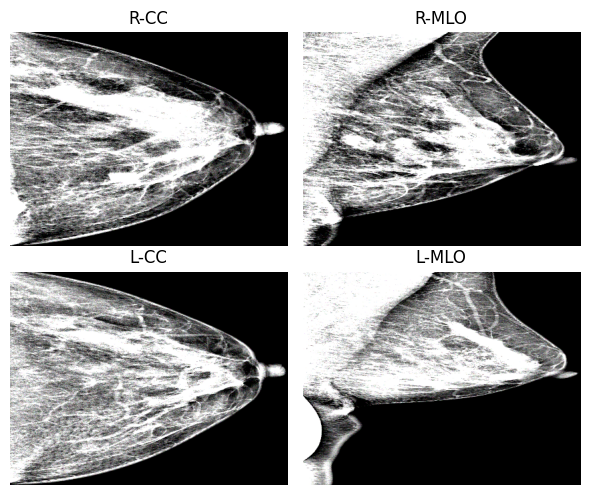

In [211]:
# Plot all 4 views of the sample study
pyplot.figure(figsize=(6, 5))
for i, (_, row) in enumerate(study_images.iterrows()):
    image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)

    # Resize image using Lanczos interpolation and expand to 3 channels
    image = cv2.resize(image, (416, 320), interpolation=cv2.INTER_LANCZOS4)
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    # Align the breast to the left
    if row["laterality"].upper() == "R":
        image = cv2.flip(image, 1)
    
    # Apply Contrasted Limited Adaptive Histogram Equalization (CLAHE)
    k = 8.0
    l = 2.0
    grid_size = int(k + np.random.uniform(-np.log2(k), np.log2(k)))
    clip_limit = l + np.random.uniform(-np.log2(l), np.log2(l))
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(grid_size, grid_size))

    channels = cv2.split(image)
    channels = [clahe.apply(channel) for channel in channels]
    image = cv2.merge(channels)

    # Convert to float and normalize to [0, 1]
    image = image.astype(np.float32) / 255.0

    # Add Gaussian noise with σ=0.01 per channel
    noise = np.random.normal(0, 0.01, image.shape).astype(np.float32)
    image = np.clip(image + noise, 0.0, 1.0)

    # Standardize the image per channel (mean = 0, std = 1)
    mean = image.mean()
    std = image.std()
    image = (image - mean) / (std + 1e-8)

    title = f"{row["laterality"]}-{row["view_position"]}"

    pyplot.subplot(2, 2, i + 1)
    pyplot.imshow(np.clip(image, 0, 1), cmap="gray")
    pyplot.title(title)
    pyplot.axis("off")

pyplot.tight_layout()
pyplot.show()